# Cross-Correlation & Seasonality Analysis
**Goal:** Understand how clouds propagate between stations and what seasonal/diurnal patterns exist.  
Understanding these lags is exactly what the GRU model will learn — this notebook makes it explicit.

- **Target station:** Spain (41.93°N, -4.26°W)
- **Neighbour station:** Atlantic (45.93°N, -40.26°W)

In [1]:
import sys
sys.path.append('..')   # so we can import src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import ccf, acf

from src.loader import load_all
from src.features import engineer

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
DATA_DIR  = '../data'
TARGET_ID = '41.93'

## 1. Load data

In [2]:
target_raw, neighbor_raws = load_all(DATA_DIR, TARGET_ID)
neighbour_raw = neighbor_raws[0]   # Atlantic station

spain    = engineer(target_raw)
atlantic = engineer(neighbour_raw)

# Align on shared timestamps
idx = spain.index.intersection(atlantic.index)
spain    = spain.loc[idx]
atlantic = atlantic.loc[idx]

# Separate daytime only (Clearsky GHI > 1 W/m²)
is_day = target_raw.loc[idx, 'Clearsky GHI'] > 1.0

print(f'Total hours   : {len(spain)}')
print(f'Daytime hours : {is_day.sum()}')
spain[['kt', 'Cloud Type', 'GHI', 'Clearsky GHI']].describe()

[loader] Target   : 231955_41.93_-4.26_tdy-2022.csv  (8760 rows)
[loader] Neighbor : 231954_45_-40.26_tdy-2022.csv  (8760 rows)
Total hours   : 8760
Daytime hours : 4369


,kt,Cloud Type,GHI,Clearsky GHI
count,8760.000000,8760.000000,8760.000000,8760.000000
mean,0.352959,2.758447,183.661416,238.800571
std,0.429056,2.979338,279.250028,313.898612
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000
75%,0.899978,6.000000,323.000000,455.000000
max,0.999032,9.000000,1032.000000,1032.000000


## 2. Time series overview — kt at both stations

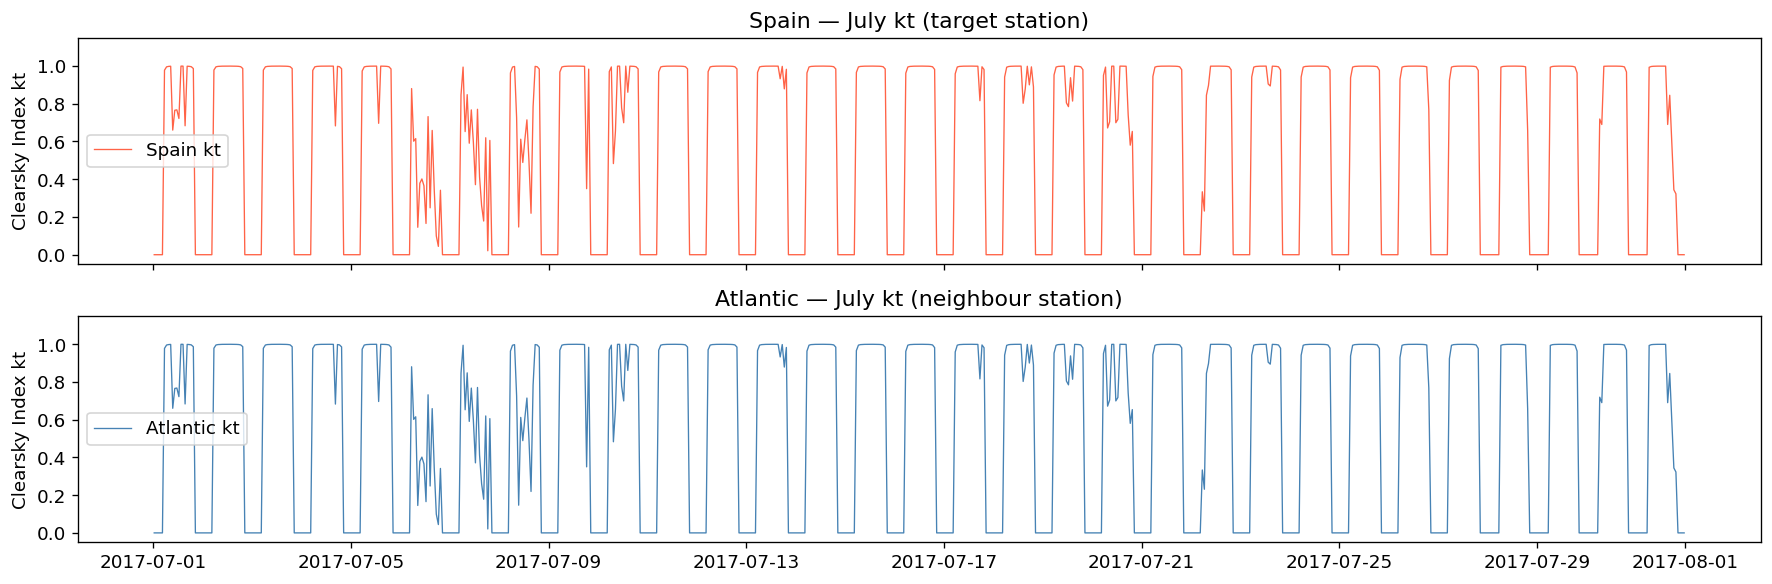

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

# Show one representative month (July — most variability)
mask = (spain.index.month == 7)
t = spain.index[mask]

axes[0].plot(t, spain.loc[mask, 'kt'], color='tomato', lw=0.8, label='Spain kt')
axes[0].set_ylabel('Clearsky Index kt')
axes[0].set_title('Spain — July kt (target station)')
axes[0].set_ylim(-0.05, 1.15)
axes[0].legend()

axes[1].plot(t, atlantic.loc[mask, 'kt'], color='steelblue', lw=0.8, label='Atlantic kt')
axes[1].set_ylabel('Clearsky Index kt')
axes[1].set_title('Atlantic — July kt (neighbour station)')
axes[1].set_ylim(-0.05, 1.15)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Cross-Correlation Function (CCF)

CCF at lag $h$ measures the correlation between **Atlantic kt at time $t$** and **Spain kt at time $t+h$**.

A peak at lag $h > 0$ means: "Atlantic clouds arrive at Spain ~$h$ hours later" — exactly the signal the GRU model should exploit.

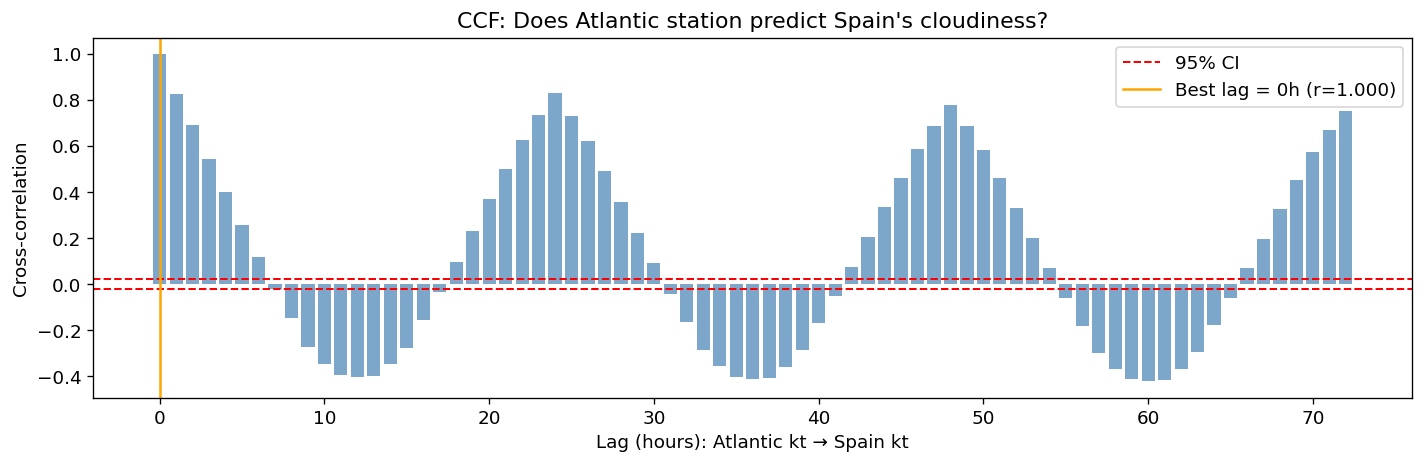

Peak cross-correlation: r = 1.0000 at lag = 0 h
Interpretation: Atlantic kt at t is most correlated with Spain kt at t+0h


In [4]:
MAX_LAG = 72   # look up to 72 h ahead

kt_spain    = spain['kt'].values
kt_atlantic = atlantic['kt'].values

# --- CCF manually: corr(atlantic[t], spain[t+lag]) for lag = 0..MAX_LAG ---
def cross_corr(x, y, max_lag):
    x_z = (x - x.mean()) / (x.std() + 1e-8)
    y_z = (y - y.mean()) / (y.std() + 1e-8)
    vals = []
    for lag in range(max_lag + 1):
        if lag == 0:
            vals.append(float(np.mean(x_z * y_z)))
        else:
            vals.append(float(np.mean(x_z[:-lag] * y_z[lag:])))
    return np.array(vals)

ccf_vals = cross_corr(kt_atlantic, kt_spain, MAX_LAG)
lags     = np.arange(MAX_LAG + 1)
ci_bound = 1.96 / np.sqrt(len(kt_spain))   # standard 95% CI for correlation

best_lag  = int(np.argmax(np.abs(ccf_vals)))
best_corr = ccf_vals[best_lag]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(lags, ccf_vals, color='steelblue', alpha=0.7, width=0.8)
ax.axhline( ci_bound, color='red', ls='--', lw=1.2, label='95% CI')
ax.axhline(-ci_bound, color='red', ls='--', lw=1.2)
ax.axvline(best_lag, color='orange', lw=1.5, label=f'Best lag = {best_lag}h (r={best_corr:.3f})')
ax.set_xlabel('Lag (hours): Atlantic kt → Spain kt')
ax.set_ylabel('Cross-correlation')
ax.set_title("CCF: Does Atlantic station predict Spain's cloudiness?")
ax.legend()
plt.tight_layout()
plt.show()

print(f'Peak cross-correlation: r = {best_corr:.4f} at lag = {best_lag} h')
print(f'Interpretation: Atlantic kt at t is most correlated with Spain kt at t+{best_lag}h')

## 4. Lagged scatter plot
Visual confirmation of the best lag found above.

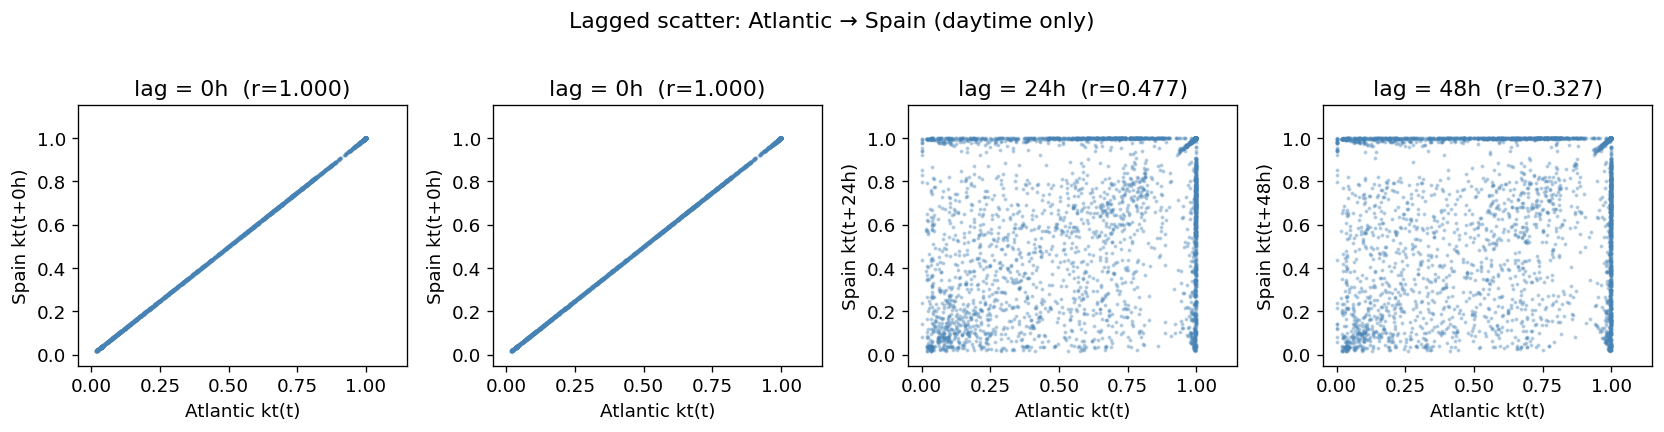

In [5]:
lags_to_show = [0, best_lag, 24, 48]
fig, axes = plt.subplots(1, len(lags_to_show), figsize=(14, 3.5))

for ax, lag in zip(axes, lags_to_show):
    x = kt_atlantic[:-lag if lag > 0 else len(kt_atlantic)]
    y = kt_spain[lag:] if lag > 0 else kt_spain
    # daytime only
    day = is_day.values[lag:] if lag > 0 else is_day.values
    x, y = x[day], y[day]
    r = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=2, alpha=0.3, color='steelblue')
    ax.set_title(f'lag = {lag}h  (r={r:.3f})')
    ax.set_xlabel('Atlantic kt(t)')
    ax.set_ylabel(f'Spain kt(t+{lag}h)')
    ax.set_xlim(-0.05, 1.15)
    ax.set_ylim(-0.05, 1.15)

plt.suptitle('Lagged scatter: Atlantic → Spain (daytime only)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Autocorrelation of Spain kt
How persistent is the cloudiness state at the target station itself?  
High ACF at lag 1 → persistence baseline is hard to beat.

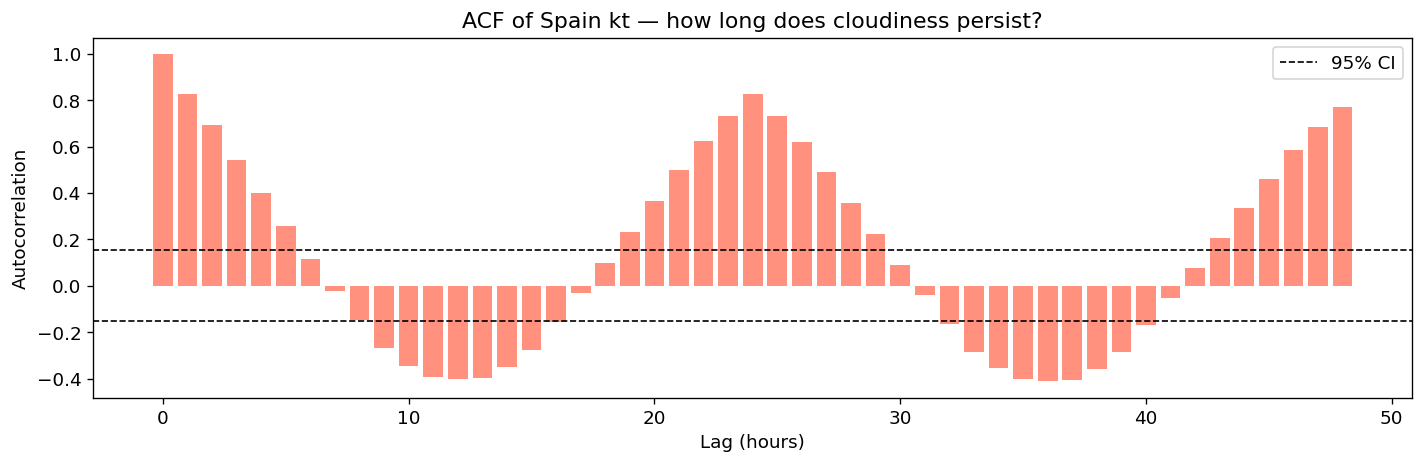

ACF at lag 1h  : 0.8267
ACF at lag 6h  : 0.1160
ACF at lag 24h : 0.8265

High ACF at lag 1h means persistence is a very strong baseline at 1h horizon.
Falling ACF at 6h and 24h means those horizons are genuinely hard to predict.


In [6]:
acf_vals, acf_ci = acf(kt_spain, nlags=48, alpha=0.05)
lags_acf = np.arange(len(acf_vals))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(lags_acf, acf_vals, color='tomato', alpha=0.7, width=0.8)
ax.axhline(acf_ci[1, 1] - acf_vals[0], color='black', ls='--', lw=1, label='95% CI')
ax.axhline(-(acf_ci[1, 1] - acf_vals[0]), color='black', ls='--', lw=1)
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Autocorrelation')
ax.set_title('ACF of Spain kt — how long does cloudiness persist?')
ax.legend()
plt.tight_layout()
plt.show()

print(f'ACF at lag 1h  : {acf_vals[1]:.4f}')
print(f'ACF at lag 6h  : {acf_vals[6]:.4f}')
print(f'ACF at lag 24h : {acf_vals[24]:.4f}')
print()
print('High ACF at lag 1h means persistence is a very strong baseline at 1h horizon.')
print('Falling ACF at 6h and 24h means those horizons are genuinely hard to predict.')

## 6. Seasonality — diurnal cycle
Mean kt and GHI by hour of day, for all months. Shows the daily bell curve and how it shifts by season.

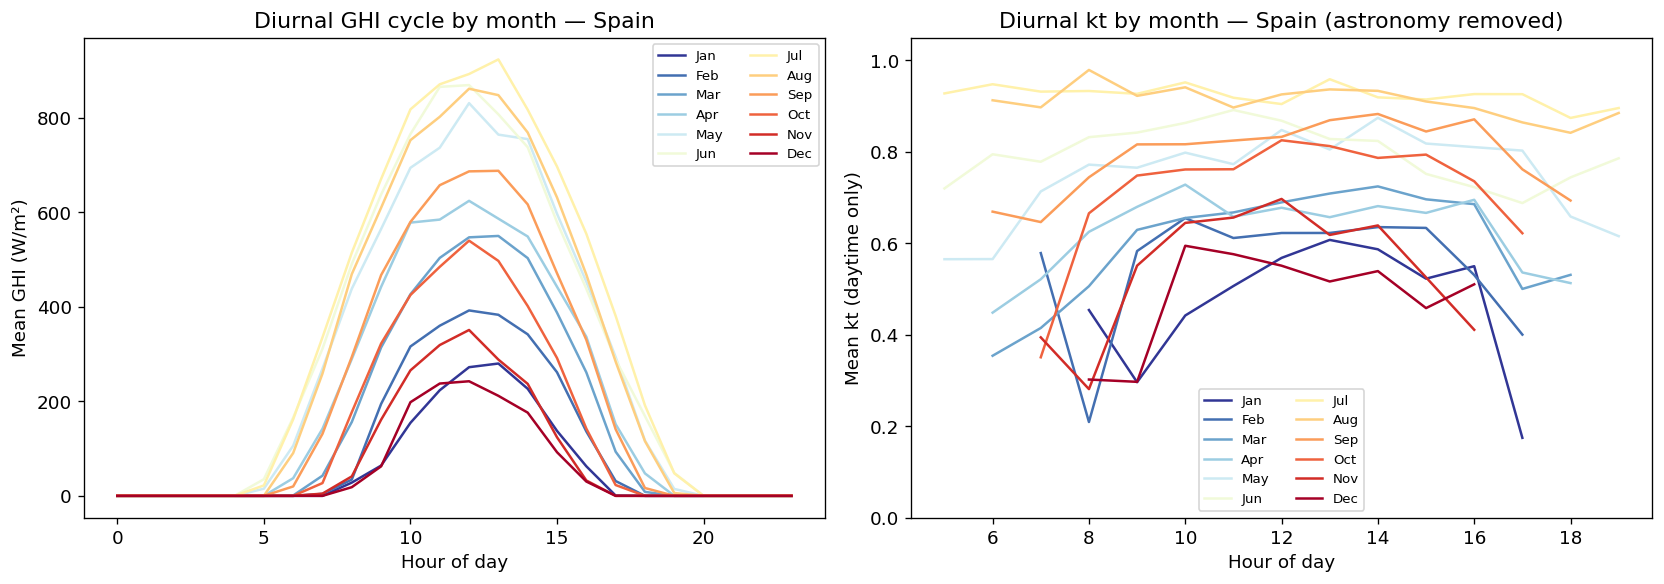

In [7]:
spain['hour']  = spain.index.hour
spain['month'] = spain.index.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GHI by hour and month
cmap = plt.get_cmap('RdYlBu_r', 12)
for m in range(1, 13):
    sub = spain[spain['month'] == m]
    hourly = sub.groupby('hour')['GHI'].mean()
    axes[0].plot(hourly.index, hourly.values, color=cmap(m-1), label=month_names[m-1], lw=1.5)

axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Mean GHI (W/m²)')
axes[0].set_title('Diurnal GHI cycle by month — Spain')
axes[0].legend(fontsize=8, ncol=2)

# kt by hour and month (cloud signal, astronomy removed)
for m in range(1, 13):
    sub = spain[(spain['month'] == m) & is_day]
    hourly_kt = sub.groupby('hour')['kt'].mean()
    if len(hourly_kt) > 0:
        axes[1].plot(hourly_kt.index, hourly_kt.values, color=cmap(m-1), label=month_names[m-1], lw=1.5)

axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Mean kt (daytime only)')
axes[1].set_title('Diurnal kt by month — Spain (astronomy removed)')
axes[1].legend(fontsize=8, ncol=2)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 7. Seasonality — monthly cloud patterns

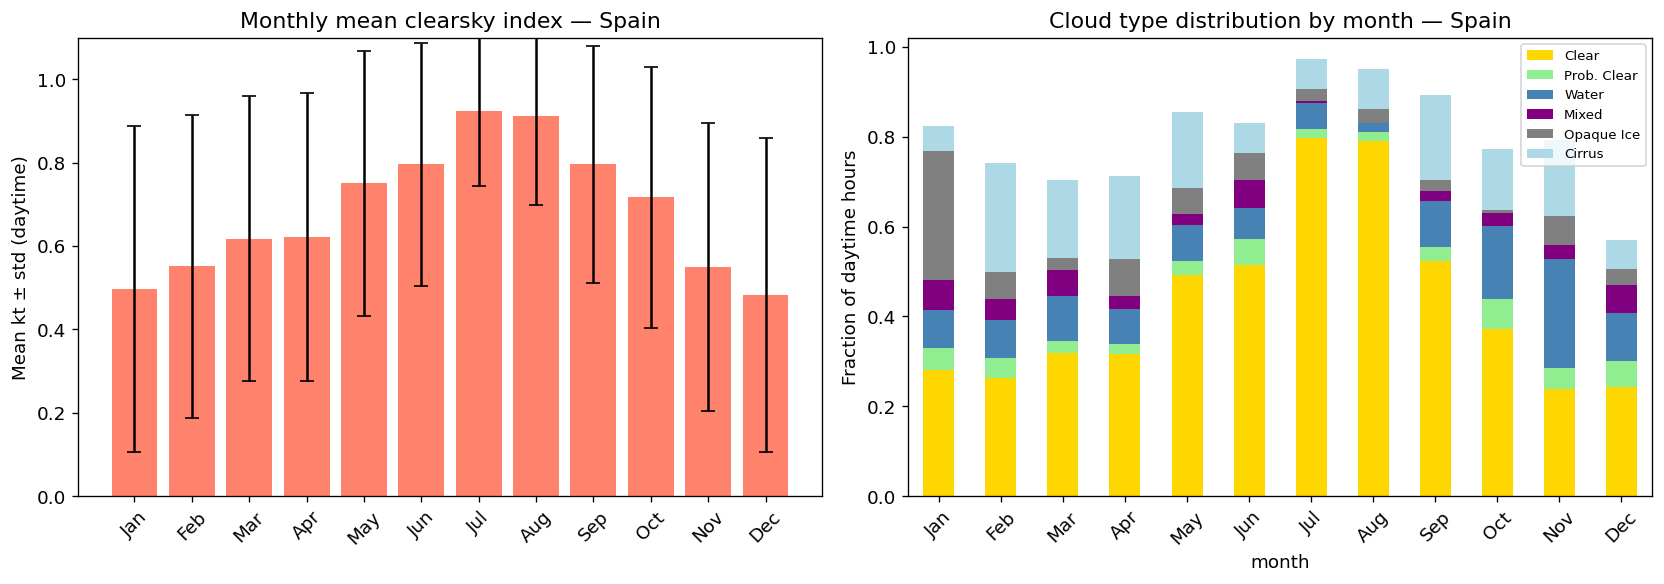

In [8]:
# Cloud type labels from NSRDB
cloud_labels = {
    0: 'Clear', 1: 'Prob. Clear', 2: 'Fog', 3: 'Water', 4: 'SC Water',
    5: 'Mixed', 6: 'Opaque Ice', 7: 'Cirrus', 8: 'Overlapping',
    9: 'Overshooting', 10: 'Unknown', 11: 'Dust', 12: 'Smoke'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean kt per month
monthly_kt = spain[is_day].groupby('month')['kt'].agg(['mean', 'std'])
axes[0].bar(monthly_kt.index, monthly_kt['mean'], yerr=monthly_kt['std'],
            color='tomato', alpha=0.8, capsize=4)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, rotation=45)
axes[0].set_ylabel('Mean kt ± std (daytime)')
axes[0].set_title('Monthly mean clearsky index — Spain')
axes[0].set_ylim(0, 1.1)

# Cloud type frequency by month (daytime only)
ct_monthly = (
    spain[is_day]
    .groupby(['month', 'Cloud Type'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
# Keep only meaningful cloud types
keep = [0, 1, 3, 5, 6, 7]
keep = [c for c in keep if c in ct_monthly.columns]
ct_monthly[keep].plot.bar(stacked=True, ax=axes[1],
    color=['gold','lightgreen','steelblue','purple','gray','lightblue'],
    legend=True)
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_ylabel('Fraction of daytime hours')
axes[1].set_title('Cloud type distribution by month — Spain')
axes[1].legend([cloud_labels.get(c, str(c)) for c in keep], fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## 8. STL Decomposition — Spain kt
Decompose the full kt series into **trend + seasonal + residual**.  
The residual is the truly unpredictable part — what clouds add on top of the astronomical signal.

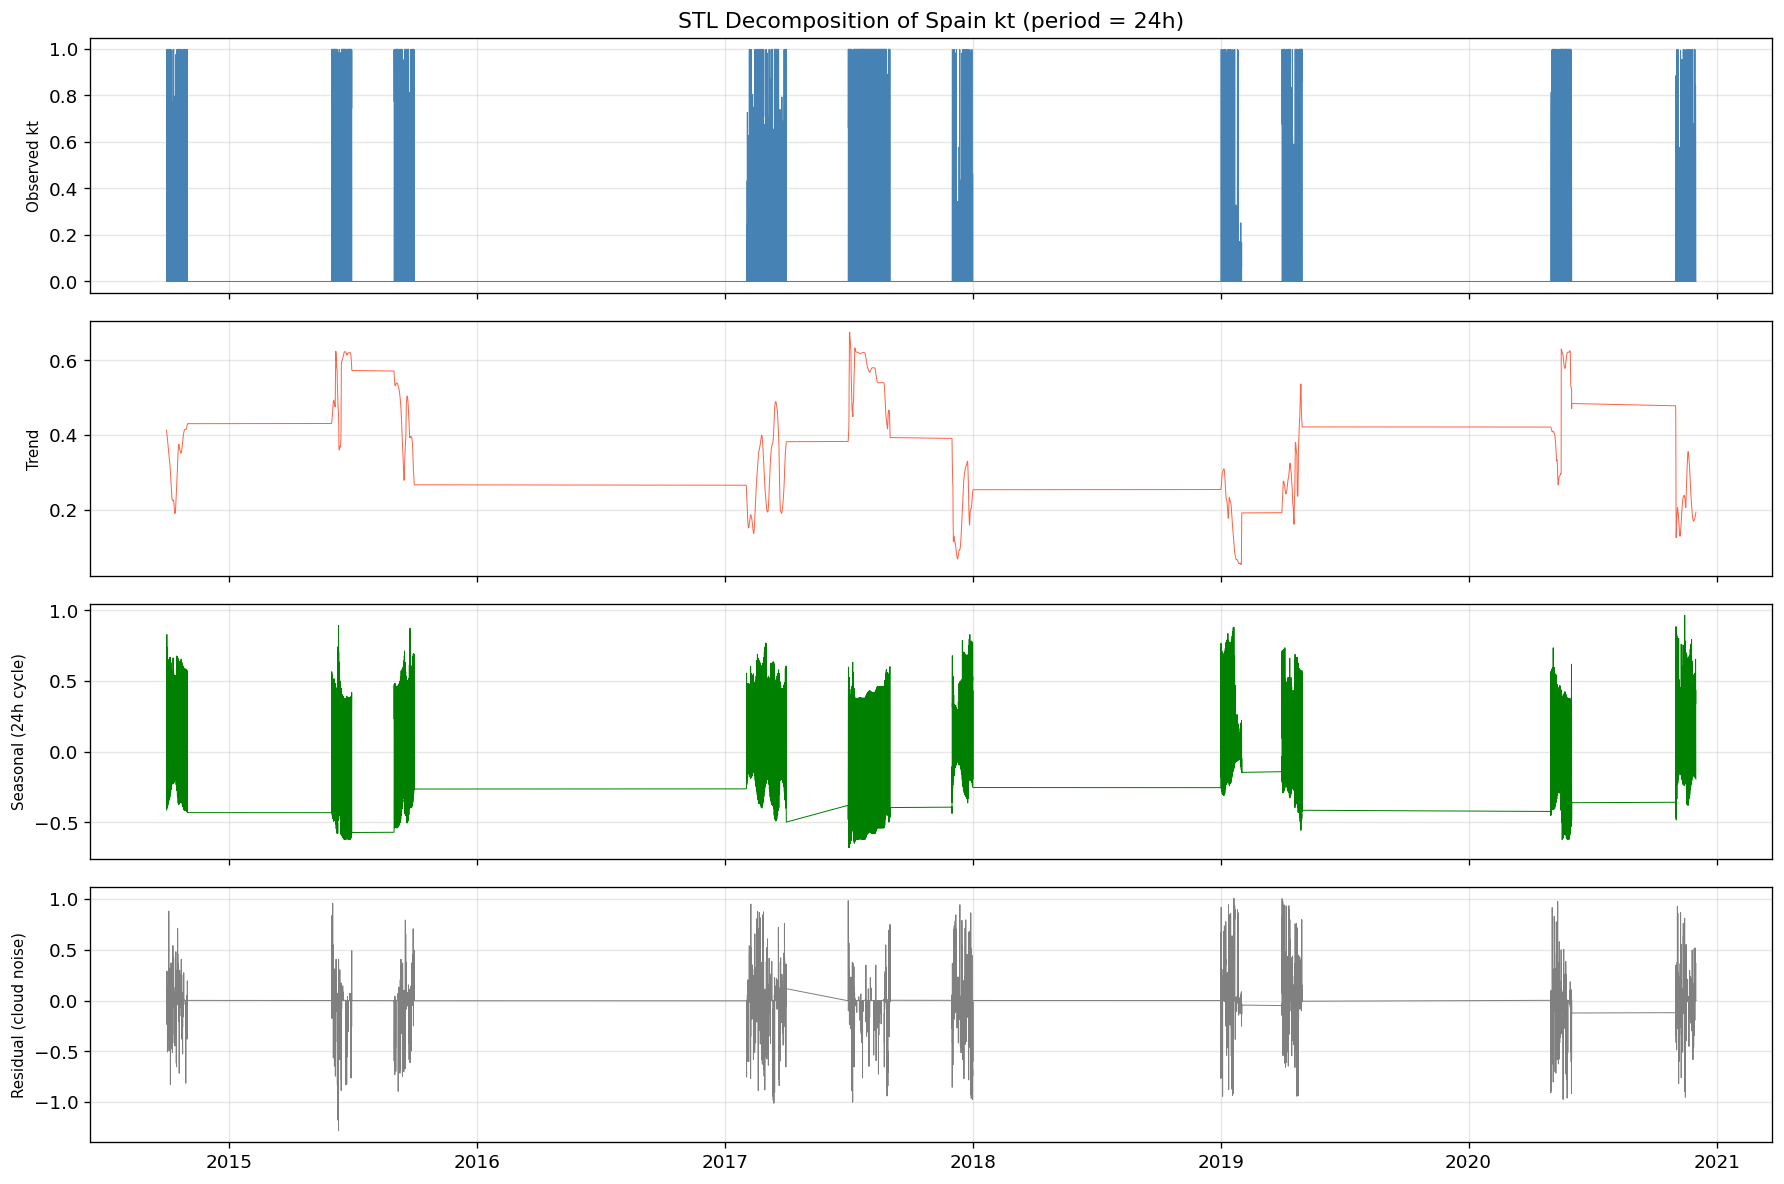

Variance explained:
  Trend    : 14.7%
  Seasonal : 82.6%
  Residual : 19.6%  ← the cloud forecasting challenge


In [9]:
# STL works best on a stationary, evenly-spaced series
# Use the full kt series (including night zeros); period = 24h
stl = STL(spain['kt'], period=24, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
components = [
    (spain['kt'],  'Observed kt',         'steelblue'),
    (res.trend,    'Trend',               'tomato'),
    (res.seasonal, 'Seasonal (24h cycle)', 'green'),
    (res.resid,    'Residual (cloud noise)','gray'),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(spain.index, data, color=color, lw=0.6)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title('STL Decomposition of Spain kt (period = 24h)')
plt.tight_layout()
plt.show()

# Variance explained
total_var    = np.var(spain['kt'])
trend_var    = np.var(res.trend)
seasonal_var = np.var(res.seasonal)
resid_var    = np.var(res.resid)
print(f'Variance explained:')
print(f'  Trend    : {100*trend_var/total_var:.1f}%')
print(f'  Seasonal : {100*seasonal_var/total_var:.1f}%')
print(f'  Residual : {100*resid_var/total_var:.1f}%  ← the cloud forecasting challenge')

## 9. Cloud-driven kt drops — distribution by season
When clouds hit, how severe is the drop in kt?

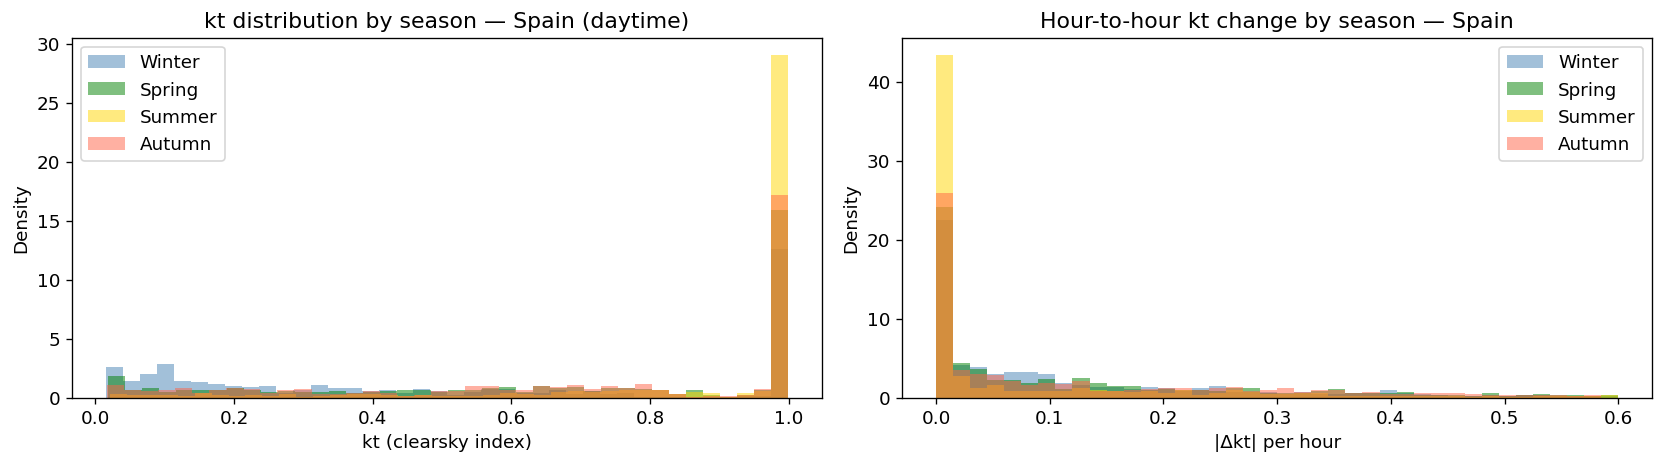

Mean |Δkt| per season (daytime):
  Winter  : 0.1833
  Spring  : 0.1652
  Summer  : 0.1265
  Autumn  : 0.1670


In [10]:
spain['season'] = spain['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn',
})
season_order  = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['steelblue', 'green', 'gold', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# kt distribution per season (daytime only)
for season, color in zip(season_order, season_colors):
    sub = spain[is_day & (spain['season'] == season)]['kt']
    axes[0].hist(sub, bins=40, alpha=0.5, label=season, color=color, density=True)
axes[0].set_xlabel('kt (clearsky index)')
axes[0].set_ylabel('Density')
axes[0].set_title('kt distribution by season — Spain (daytime)')
axes[0].legend()

# kt drop: hour-to-hour difference (absolute change)
spain['kt_diff'] = spain['kt'].diff().abs()
for season, color in zip(season_order, season_colors):
    sub = spain[is_day & (spain['season'] == season)]['kt_diff'].dropna()
    axes[1].hist(sub, bins=40, alpha=0.5, label=season, color=color, density=True, range=(0, 0.6))
axes[1].set_xlabel('|Δkt| per hour')
axes[1].set_ylabel('Density')
axes[1].set_title('Hour-to-hour kt change by season — Spain')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Mean |Δkt| per season (daytime):')
for season in season_order:
    sub = spain[is_day & (spain['season'] == season)]['kt_diff'].dropna()
    print(f'  {season:<8}: {sub.mean():.4f}')

## 10. What the model learns from these statistics

| Finding | What the GRU learns |
|---|---|
| CCF peak lag | How many hours back to weight the neighbour station's kt |
| High ACF at lag 1h | Persistence is a strong baseline — model must beat it |
| Falling ACF at 6–24h | Longer horizons are harder; model needs more features |
| Seasonal kt pattern | Summer = clearer; winter = cloudier (trend encoder) |
| Cloud type distribution | Which cloud types cause the deepest kt drops |
| Residual variance | This is the irreducible cloud noise — sets the error floor |

The **lookback window** (default 24h) is chosen to capture the ACF decay.  
The **neighbour GRU** is designed to exploit the CCF lag signal.  
The **cyclical time features** (sin/cos hour, sin/cos doy) encode the diurnal and seasonal components shown above, so the GRU can focus its capacity on the residual cloud signal.